# Layer 27：三面板实验汇总

所有绘图代码直接定义在本 notebook 中；修改参数后重跑即可。读取现有统计结果，不重新运行模型。PDF 优先保存，随后以内嵌 SVG 预览。

- **(a)** 使用 100 条不同 HarmBench 文本作为追加 prompt，重新计算 mixed steering 与 prompt-length 的维度曲线。每条文本按请求正文、上下文顺序排列；128-token 前缀共 100 种，较短前缀可能相同。7 条短文本追加了 manifest 中逐字记录的中性说明。原来的 100 个输入与这些追加 prompt 按循环错位配对，原输入/生成表示和参考 query 固定，只替换 prompt 表示；这是 100 对样本，而不是 100×100 全交叉实验。每个样本先平均 head 0、16，再跨样本计算 mean ± sample std。两个轴均为线性，刻度间隔均为 32。统计来自独立的 `section4_prompt_diversity_summary.json`，不使用旧的固定追加指令结果。
- **(b)** 只保留 **4 prompt、1 input + 3 generated**。固定原生 attention 上优化的 r，只比较 sensitive、random 扰动，省略 null。纵轴为 log，横轴保留能显示零的 symlog。每个点的横坐标是平均 rho；纵坐标与阴影是 100 个样本的误差 mean ± sample std（不是置信区间）。原始 std 已在结果中保存，旧图没有显示，此图补上。
- **(c)** 合并 `section4_attention_bounds.ipynb` 中 layer 27 的左右图：保留 input-only 和 **4 input + generated** 的 measured error，以及 prompt-length measured error，共三条曲线；不显示 bound。steering 使用 95 个样本，prompt 使用 400 个样本；阴影沿用各自 cohort 的 mean ± sample std。x 为 log₂，y 为 log。

**方法边界：** (a) 是原线性理论的子空间诊断，(b) 是含 QK normalization / RoPE 的原生 attention，(c) 是旧的固定状态线性 attention 实验。两种误差对应不同实验设置，不能混为同一实验。原生实验拟合两个 head（0、16），存在未达容差的拟合和大量 EOS 后位置；此处不作自然生成行为或精确匹配的保证。

对数轴无法显示非正数，mean − std ≤ 0 的阴影仅在显示时裁至正的坐标下限，原始统计值不变。零维度仅出现在使用线性轴的 (a)。

In [1]:
from pathlib import Path
import io
import json

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "results/section4_native_summary.json").exists())
native = json.loads((ROOT / "results/section4_native_summary.json").read_text())
diversity = json.loads((ROOT / "results/section4_prompt_diversity_summary.json").read_text())
assert diversity["formal"] and diversity["examples"] == 100
assert diversity["distinct_prompt_prefixes"]["128"] == 100
legacy = json.loads((ROOT / "results/section4_long_summary.json").read_text())
assert native["examples"] == 100 and native["layer"] == 26

LENGTHS = [1, 2, 4, 8, 16, 32, 64, 128]
DRIFT_CONDITION = "m4_b1_g3"
COLORS = {"input": "#2673B8", "mixed": "#D97721", "prompt": "#7B4FA3",
          "null": "#2673B8", "sensitive": "#D97721", "random": "#7B4FA3"}
STYLE = {"font.family": "DejaVu Sans", "font.size": 11, "axes.labelsize": 12,
         "legend.fontsize": 9, "pdf.fonttype": 42,
         "axes.spines.top": False, "axes.spines.right": False}
FIGSIZE = (16, 4.5)
PDF_PATH = ROOT / "figs/section4_layer27_summary.pdf"

In [2]:
def draw(ax, rows, field, x_position, label, color, *, bound=False, floor=0):
    rows = sorted(rows, key=x_position)
    x = np.array([x_position(row) for row in rows])
    mean = np.array([row[field]["mean"] for row in rows])
    std = np.array([row[field]["std"] for row in rows])
    ax.plot(x, mean, color=color, label=label, linewidth=1.6,
            linestyle="--" if bound else "-", marker="s" if bound else "o",
            markersize=3.5, markerfacecolor="white" if bound else color, zorder=3)
    if len(x) and np.all(x == x[0]):
        ax.vlines(x, np.maximum(mean-std, floor), mean+std, color=color,
                  alpha=.3, linewidth=4, zorder=1)
    else:
        ax.fill_between(x, np.maximum(mean-std, floor), mean+std,
                        color=color, alpha=.07 if bound else .13, linewidth=0, zorder=1)


def log_range(moments):
    means = [r["mean"] for r in moments]
    if not all(value > 0 for value in means):
        raise ValueError("Nonpositive mean cannot be shown on a log axis")
    return min(means)/2, max(r["mean"]+r["std"] for r in moments)*1.25


def make_figure():
    with plt.rc_context(STYLE):
        fig, axes = plt.subplots(1, 3, figsize=FIGSIZE,
                                 gridspec_kw={"width_ratios": [1, 1.05, 1.2]})
        a, b, c = axes
        rows = diversity["token_statistics"]
        mixed = [r for r in rows if r["m"]==4 and r["b"]==1]
        prompt = [r for r in rows if r["b"]==1 and r["g"]==0]
        draw(a, mixed, "dimension", lambda r:r["b"]+r["g"],
             "1 input + generated", COLORS["mixed"])
        draw(a, prompt, "dimension", lambda r:r["m"], "Prompt length", COLORS["prompt"])
        a.set(xlabel="Token count", ylabel="Dimension of original linear U⊥",
              xlim=(-3,131), ylim=(-3,131))
        a.set_xticks([0,32,64,96,128]); a.set_yticks([0,32,64,96,128])
        a.legend(frameon=False, loc="upper right")

        drift = [r for r in native["drift_statistics"] if r["condition"]==DRIFT_CONDITION and r["direction"]!="null"]
        floor, ceiling = log_range([r["native_error"] for r in drift])
        b.set_xscale("symlog", linthresh=.01)
        b.set_yscale("log")
        b.set_ylim(floor, ceiling)
        for direction in ["sensitive", "random"]:
            draw(b, [r for r in drift if r["direction"]==direction], "native_error",
                 lambda r:0 if r["rho"]["mean"]<1e-9 else r["rho"]["mean"],
                 direction, COLORS[direction], floor=floor)
        b.set(xlabel="Distance ρ to original linear U⊥", ylabel="Native attention L₂ error")
        b.legend(frameon=False, loc="upper left")

        rows = [r for r in legacy["comparison"] if r["layer"]==26]
        steering = [r for r in rows if r["figure"]=="steering"]
        prompt = [r for r in rows if r["figure"]=="prompt"]
        moments = [r["error"] for r in steering]
        moments += [r["error"] for r in prompt]
        floor, ceiling = log_range(moments)
        c.set_xscale("log", base=2); c.set_yscale("log")
        c.set_ylim(floor, ceiling*2.5)
        for series, color, label in [
            ([r for r in steering if r["g"]==0], COLORS["input"], "input only"),
            ([r for r in steering if r["g"] or r["k"]==4], COLORS["mixed"], "4 input + gen.")]:
            draw(c, series, "error", lambda r:r["k"]+r["g"], f"Measured · {label}",
                 color, floor=floor)
        draw(c, prompt, "error", lambda r:r["m"], "Measured · prompt length",
             COLORS["prompt"], floor=floor)
        c.set_xticks(LENGTHS, labels=[str(x) for x in LENGTHS])
        c.set(xlabel="Token count", ylabel="Linear attention L₂ error")
        c.legend(frameon=False, loc="upper left", fontsize=8.5, ncol=1,
                 columnspacing=.8, handlelength=2)

        for ax, label in zip(axes, ["(a)", "(b)", "(c)"]):
            ax.grid(axis="y", alpha=.2)
            ax.set_axisbelow(True)
            ax.text(.5, -.25, label, transform=ax.transAxes, ha="center", va="top", fontsize=12)
        fig.subplots_adjust(left=.055, right=.99, bottom=.26, top=.88, wspace=.35)
    return fig

Saved figs/section4_layer27_summary.pdf


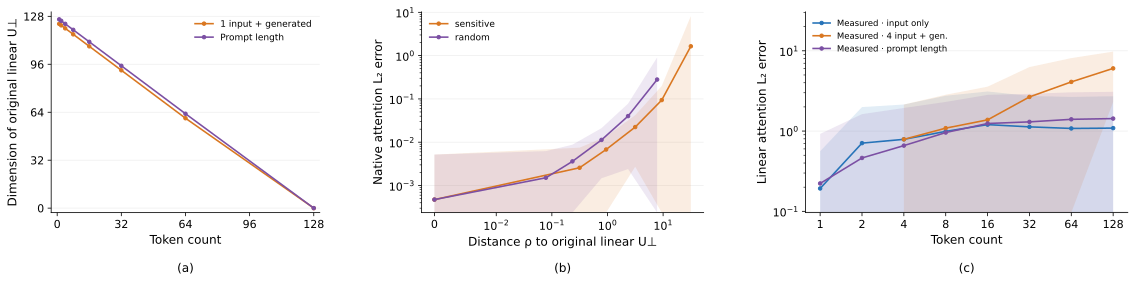

In [3]:
fig = make_figure()
fig.savefig(PDF_PATH, bbox_inches="tight")
print(f"Saved {PDF_PATH.relative_to(ROOT)}")
preview = io.StringIO()
fig.savefig(preview, format="svg", bbox_inches="tight")
display(SVG(preview.getvalue()))
plt.close(fig)